In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid")


In [2]:
df = pd.read_csv("../dataset/processed/cardio_cleaned.csv")

# Advanced Clinical Features
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]
df["map_pressure"] = ((2 * df["ap_lo"]) + df["ap_hi"]) / 3.0
df["map_pressure"] = df["map_pressure"].round(2)

# Final Feature List
feature_cols = [
    "age_years", "gender", "height", "weight", "ap_hi", "ap_lo",
    "cholesterol", "gluc", "smoke", "alco", "active", "bmi",
    "pulse_pressure", "map_pressure"
]

X = df[feature_cols]
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Training shape: {X_train.shape} | Testing shape: {X_test.shape}")


Features (14): ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure', 'map_pressure']
Training shape: (54843, 14) | Testing shape: (13711, 14)


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Parameter Grid to search
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [10, 14, 18],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

print("Starting Hyperparameter Tuning...")
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print("\n✅ Best Hyperparameters Found:")
print(grid_search.best_params_)
print(f"Best 5-Fold Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")


Starting Hyperparameter Tuning...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best Hyperparameters Found:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 150}
Best 5-Fold Cross-Validation ROC-AUC: 0.7994


In [6]:
# Predictions
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("=== FINAL MODEL TEST PERFORMANCE ===")
print(f"Accuracy  : {acc * 100:.2f}%")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Healthy (0)", "Cardiovascular Disease (1)"]))


=== FINAL MODEL TEST PERFORMANCE ===
Accuracy  : 73.34%
Precision : 0.7586
Recall    : 0.6760
F1 Score  : 0.7149
ROC-AUC   : 0.8012

=== Detailed Classification Report ===
                            precision    recall  f1-score   support

               Healthy (0)       0.71      0.79      0.75      6930
Cardiovascular Disease (1)       0.76      0.68      0.71      6781

                  accuracy                           0.73     13711
                 macro avg       0.74      0.73      0.73     13711
              weighted avg       0.74      0.73      0.73     13711



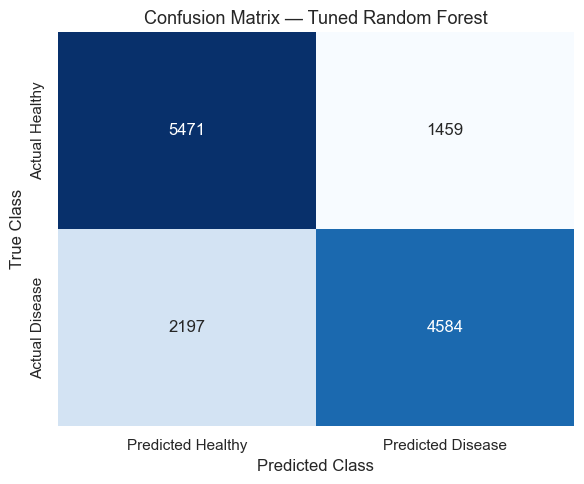

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Healthy", "Predicted Disease"],
            yticklabels=["Actual Healthy", "Actual Disease"])
plt.title("Confusion Matrix — Tuned Random Forest", fontsize=13)
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()


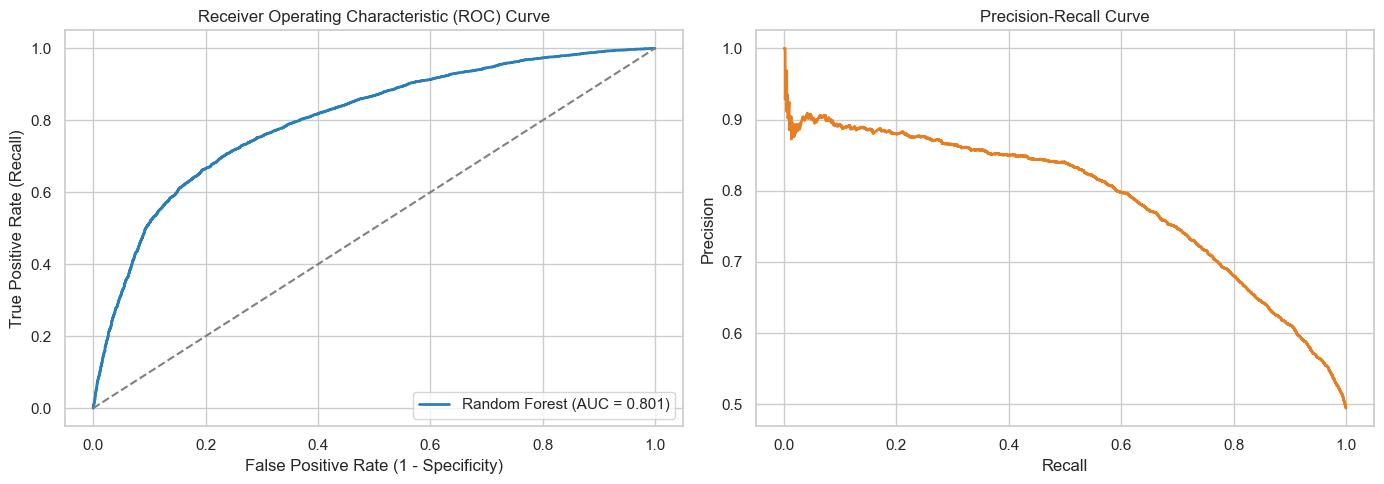

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color="#2980b9", lw=2, label=f"Random Forest (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[0].set_title("Receiver Operating Characteristic (ROC) Curve")
axes[0].set_xlabel("False Positive Rate (1 - Specificity)")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].legend(loc="lower right")

# 2. Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(recall_vals, precision_vals, color="#e67e22", lw=2)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.show()


In [9]:
# 1. Create models directory
os.makedirs("../models", exist_ok=True)

# 2. Save Trained Model
model_path = "../models/trained_model.pkl"
joblib.dump(best_model, model_path)
print(f"✅ Model saved to: {model_path}")

# 3. Save StandardScaler
scaler_path = "../models/scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler saved to: {scaler_path}")

# 4. Save Feature Names Metadata
metadata = {
    "model_name": "Random Forest Classifier (Tuned)",
    "accuracy": round(float(acc), 4),
    "precision": round(float(prec), 4),
    "recall": round(float(rec), 4),
    "f1_score": round(float(f1), 4),
    "roc_auc": round(float(auc), 4),
    "features": feature_cols
}

metadata_path = "../models/model_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)
print(f"✅ Metadata saved to: {metadata_path}")


✅ Model saved to: ../models/trained_model.pkl
✅ Scaler saved to: ../models/scaler.pkl
✅ Metadata saved to: ../models/model_metadata.json


In [10]:
# Test loading saved artifacts
loaded_model = joblib.load("../models/trained_model.pkl")
loaded_scaler = joblib.load("../models/scaler.pkl")

# Simulated Patient: Age 58, Female (1), 160cm, 85kg, BP 150/95, High Cholesterol (3), Normal Gluc (1), Non-smoker, Active
sample_patient = pd.DataFrame([{
    "age_years": 58,
    "gender": 1,
    "height": 160,
    "weight": 85.0,
    "ap_hi": 150,
    "ap_lo": 95,
    "cholesterol": 3,
    "gluc": 1,
    "smoke": 0,
    "alco": 0,
    "active": 1,
    "bmi": round(85.0 / ((160/100)**2), 2),
    "pulse_pressure": 150 - 95,
    "map_pressure": round(((2 * 95) + 150) / 3.0, 2)
}])

# Scale sample
sample_scaled = loaded_scaler.transform(sample_patient)

# Predict
prediction = loaded_model.predict(sample_scaled)[0]
probability = loaded_model.predict_proba(sample_scaled)[0][1]

print("\n--- SIMULATED PATIENT PREDICTION TEST ---")
print(f"Prediction  : {'High Risk (Cardiovascular Disease Detected)' if prediction == 1 else 'Low Risk (Healthy)'}")
print(f"Probability : {probability * 100:.1f}% risk")



--- SIMULATED PATIENT PREDICTION TEST ---
Prediction  : High Risk (Cardiovascular Disease Detected)
Probability : 81.2% risk
